In [18]:
import pybaseball as pyb
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("white")

# Pick our pitcher, for this instance I will pick Paul Skenes

In [26]:
pyb.playerid_lookup('skenes', 'paul')

mlb_id = pyb.playerid_lookup('skenes', 'paul')["key_mlbam"].iloc[0]
mlb_fname = pyb.playerid_lookup('skenes', 'paul')["name_first"].iloc[0].capitalize()
mlb_lname = pyb.playerid_lookup('skenes', 'paul')["name_last"].iloc[0].capitalize()

# Setting Colors

We will utilize the colors set by TJStats as I respect his work a lot.

@TJStats on Twitter/X

In [20]:
pitch_colours = {
    ## Fastballs ##
    'FF': {'colour': '#FF007D', 'name': '4-Seam Fastball'},
    'FA': {'colour': '#FF007D', 'name': 'Fastball'},
    'SI': {'colour': '#98165D', 'name': 'Sinker'},
    'FC': {'colour': '#BE5FA0', 'name': 'Cutter'},

    ## Offspeed ##
    'CH': {'colour': '#F79E70', 'name': 'Changeup'},
    'FS': {'colour': '#FE6100', 'name': 'Splitter'},
    'SC': {'colour': '#F08223', 'name': 'Screwball'},
    'FO': {'colour': '#FFB000', 'name': 'Forkball'},

    ## Sliders ##
    'SL': {'colour': '#67E18D', 'name': 'Slider'},
    'ST': {'colour': '#1BB999', 'name': 'Sweeper'},
    'SV': {'colour': '#376748', 'name': 'Slurve'},

    ## Curveballs ##
    'KC': {'colour': '#311D8B', 'name': 'Knuckle Curve'},
    'CU': {'colour': '#3025CE', 'name': 'Curveball'},
    'CS': {'colour': '#274BFC', 'name': 'Slow Curve'},
    'EP': {'colour': '#648FFF', 'name': 'Eephus'},

    ## Others ##
    'KN': {'colour': '#867A08', 'name': 'Knuckleball'},
    'PO': {'colour': '#472C30', 'name': 'Pitch Out'},
    'UN': {'colour': '#9C8975', 'name': 'Unknown'},
}

# Velocity Distribution Graph

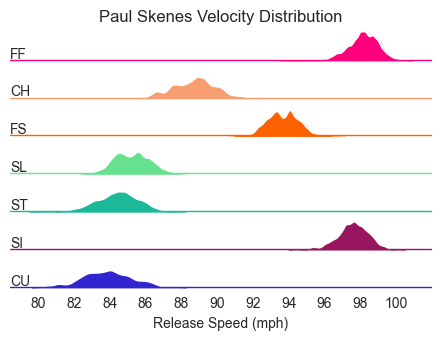

In [33]:
pitcher_stats.groupby("pitch_type").release_speed.agg("mean")

g = sns.FacetGrid(pitcher_stats, row="pitch_type",
                  hue="pitch_type", aspect=10, height=.5, palette=pitch_colors)

g.map(sns.kdeplot, "release_speed",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "release_speed", clip_on=False, color="w", lw=2, bw_adjust=.5)

g.refline(y=0, linewidth=1, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "release_speed")

g.figure.subplots_adjust(hspace=.25)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.title(f"{mlb_fname} {mlb_lname} Velocity Distribution", y=8.5)

plt.xlabel("Release Speed (mph)")

plt.xticks(range(80, 101, 2))

plt.show()